# Predicción Polinómica - datosProblema2.csv

Aquí usamos regresión polinómica para ajustar los datos del archivo `datosProblema2.csv`.

El objetivo es predecir los valores de `y` para `X = 0`, `X = 1.5`, `X = 3` y `X = 5`, y mostrar los datos junto con la curva del modelo.

## 1. Importar librerías

Importamos las herramientas necesarias para trabajar con los datos, crear el modelo polinómico y graficar los resultados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

## 2. Cargar los datos

Leemos el archivo `datosProblema2.csv` y verificamos que las columnas `X` e `y` estén correctas.

In [2]:
datos = pd.read_csv('datosProblema2.csv')
print('Primeros datos:')
print(datos.head())
print(f'Número de filas: {len(datos)}')

Primeros datos:
        X       y
0  3.8698 -0.5856
1  2.1944  0.6307
2  4.2930 -0.9890
3  3.4868 -0.0786
4  0.4709  0.3824
Número de filas: 100


## 3. Preparar el modelo polinómico

Convertimos la variable `X` a características polinómicas de grado 3 y entrenamos el modelo.

In [3]:
X = datos[['X']].values
y = datos['y'].values

grado = 3
polinomio = PolynomialFeatures(degree=grado, include_bias=False)
X_polinomico = polinomio.fit_transform(X)

modelo = LinearRegression()
modelo.fit(X_polinomico, y)

coeficiente = modelo.coef_
intercepto = modelo.intercept_

print(f'Grado del polinomio: {grado}')
print(f'Coeficientes: {coeficiente}')
print(f'Intercepto: {intercepto:.6f}')

Grado del polinomio: 3
Coeficientes: [ 1.78329401 -0.79057613  0.07836674]
Intercepto: -0.192416


## 4. Predicciones específicas

Calculamos la predicción del modelo para los valores `X = 0`, `X = 1.5`, `X = 3` y `X = 5`.

In [4]:
valores_a_predecir = np.array([[0.0], [1.5], [3.0], [5.0]])
valores_polinomicos = polinomio.transform(valores_a_predecir)
predicciones = modelo.predict(valores_polinomicos)

resultados_prediccion = pd.DataFrame({
    'X': valores_a_predecir.flatten(),
    'Prediccion': predicciones
})

print('Predicciones solicitadas:')
print(resultados_prediccion.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Predicciones solicitadas:
     X  Prediccion
0.0000     -0.1924
1.5000      0.9682
3.0000      0.1582
5.0000     -1.2445


## 5. Evaluar el ajuste

Revisamos qué tan bien el modelo polinómico se ajusta a los datos con el coeficiente R².

In [5]:
y_pred = modelo.predict(X_polinomico)
r2 = r2_score(y, y_pred)
print(f'R² del modelo: {r2:.4f}')

R² del modelo: 0.9178


## 6. Gráfica del ajuste

Mostramos los datos reales junto con la curva del modelo polinómico ajustado.

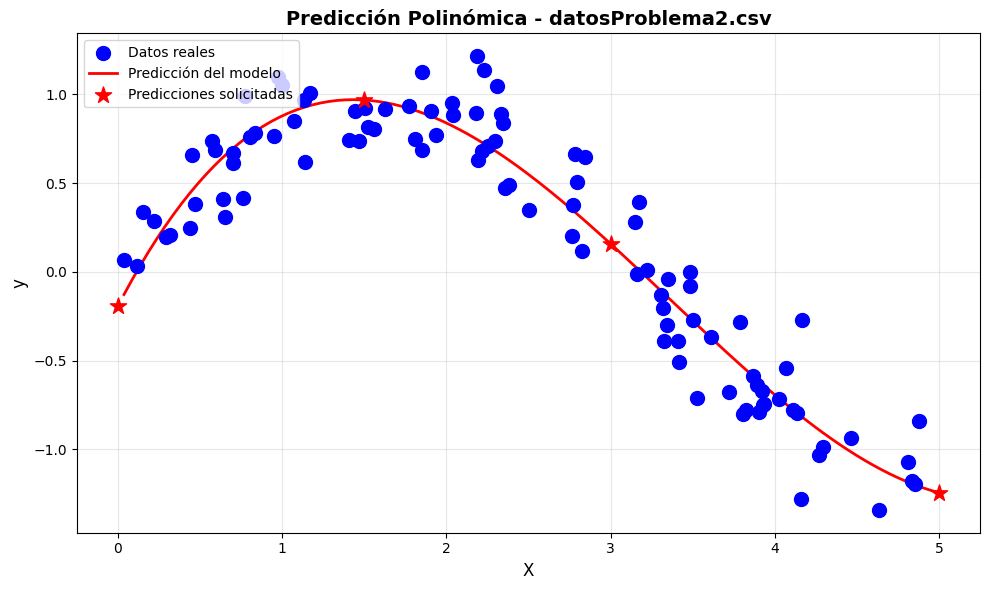

In [6]:
X_linea = np.linspace(datos['X'].min(), max(datos['X'].max(), valores_a_predecir.max()), 200).reshape(-1, 1)
X_linea_polinomico = polinomio.transform(X_linea)
y_linea = modelo.predict(X_linea_polinomico)

plt.figure(figsize=(10, 6))

# Graficar los datos reales
plt.scatter(datos['X'], datos['y'], color='blue', s=100, label='Datos reales', zorder=3)

# Graficar la curva de predicción
plt.plot(X_linea, y_linea, color='red', linewidth=2, label='Predicción del modelo')

# Señalar las predicciones solicitadas
plt.scatter(valores_a_predecir, predicciones, color='red', s=150, marker='*', zorder=4, label='Predicciones solicitadas')

plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Predicción Polinómica - datosProblema2.csv', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Resumen

Se entrenó un modelo de regresión polinómica de grado 3 con los datos de `datosProblema2.csv`.

Se presentaron las predicciones para `X = 0`, `X = 1.5`, `X = 3` y `X = 5`, y se graficó la curva del modelo junto con los puntos reales.